In [1]:
import pandas as pd

In [118]:
df_1 = pd.read_csv("kpopidolsv3.csv")
df_1.drop(['Stage Name','Country','Second Country', 'Other Group', 'Former Group', 'Gender','Full Name', 'Korean Name', 'K Stage Name', 'Date of Birth', 'Debut', 'Height', 'Weight', 'Birthplace'], 
          axis=1, inplace=True)
df_1 = df_1.drop_duplicates('Group')
df_1

,Group,Company
0,7 O'clock,Jungle
1,Limitless,ONO
2,VAV,A team
3,Hash Tag,LUK
4,MOMOLAND,Double Kick
...,...,...
1211,SNUPER,Widmay
1293,UNIQ,Yuehua
1308,G-reyish,Elijah
1373,Gfriend,Source


In [155]:
df_2 = pd.read_csv("kpop_top100_artist.csv")
df_2.drop(['Unnamed: 0', 'artist_link', 'top_track_album_link', 'top_track_link', 'top_track_explicit', 'genres'], 
          axis=1, inplace=True)
merge_followers = df_2.copy()
merge_followers.drop(['popularity', 'top_track', 'top_track_album', 'top_track_release_date', 'top_track_duration_ms'], 
          axis=1, inplace=True)
merge_followers = merge_followers.rename(columns={'artist_name': 'Group'})
merge_followers['Group'] = merge_followers['Group'].replace({'TOMORROW X TOGETHER': 'TXT'})
merge_followers['Group'] = merge_followers['Group'].replace({'NCT 127': 'NCT'})
merge_followers[merge_followers['Group'] == 'GOT7']
merge_followers

,Group,followers,top_track_popularity
0,Jimin,6227865,96
1,BTS,67507448,88
2,Jung Kook,8656152,97
3,NewJeans,4130164,93
4,LE SSERAFIM,2620665,88
...,...,...,...
95,THE BOYZ,2597408,61
96,Sunwoojunga,99003,60
97,Lim Jae Hyun,34393,47
98,Jeon Sang Keun,36354,40


In [154]:
df_13 = pd.read_csv("kpop_group_debut_astrology.csv")
df_13.drop(['company', 'group_type', 'debut_date', 'mercury_sign', 'mercury_rx', 'moon_phase', 'moon_sign', 'venus_sign', 
            'debut_day', 'debut_time', 'time_reliability', 'sun_sign', 'asc_sign', 'venus_rx', 'mars_sign', 'mars_rx', 'jupiter_sign',
           'jupiter_rx', 'saturn_sign', 'saturn_rx'], 
          axis=1, inplace=True)
df_13['group_name'] = df_13['group_name'].replace({'NCT 127': 'NCT'})
df_13_merge = df_13.rename(columns={'group_name': 'Group'})

company_data = [
    ['JYP', 0.147], #450M    
    ['SM', 0.216], #660M
    ['YG', 0.098], #300M
    #['Big Hit', 1650],
    #['Pledis', 1650],
    #['ADOR', 1650],
    #['Source', 1650],
    #['Be:lift', 1650]
    ['HYBE', 0.539] #1650M
]

df_14 = pd.DataFrame(company_data, columns=['Company', 'revenue'])

df_13_merge[df_13_merge['status'] == 'Inactive'].value_counts()

Group          status    paks  music_show_awards  end_year_awards  physical_sales  organic_youtube_views
4Minute        Inactive  0     23                 7                205088          818287184                1
AOA            Inactive  0     10                 3                223475          872310873                1
B.A.P          Inactive  0     8                  4                911467          301681895                1
BIGBANG        Inactive  7     84                 46               3514210         4589887632               1
Beast          Inactive  0     47                 28               1087745         657013261                1
Block B        Inactive  0     8                  1                418220          353939253                1
Busker Busker  Inactive  3     10                 10               344002          44241494                 1
CLC            Inactive  0     2                  0                65774           420286429                1
Crayon Pop     

In [140]:
my_data_set_1 = df_1.copy()
my_data_set_1 = my_data_set_1.reset_index(drop=True)
my_data_set_1['Group'] = my_data_set_1['Group'].replace({'Seventeen': 'SEVENTEEN'})
my_data_set_1['Group'] = my_data_set_1['Group'].replace({'Twice': 'TWICE'})
my_data_set_2 = my_data_set_1.merge(merge_followers, on='Group', how = 'left')

In [141]:
my_data_set_3 = my_data_set_2.merge(df_13_merge, on='Group', how = 'left')
my_data_set_3 = my_data_set_3.rename(columns={'organic_youtube_views': 'Youtube_view_count'})
my_data_set_3['Company'] = my_data_set_2['Company'].replace({'Big Hit': 'HYBE', 'Pledis': 'HYBE', 'ADOR': 'HYBE', 'Source': 'HYBE', 'Be:lift': 'HYBE'})
#my_data_set_3['Company'] = my_data_set_2['Company'].replace({'Pledis': 'HYBE'})
#my_data_set_3['Company'] = my_data_set_2['Company'].replace({'ADOR': 'HYBE'})
#my_data_set_3['Company'] = my_data_set_2['Company'].replace({'Source': 'HYBE'})
#my_data_set_3['Company'] = my_data_set_2['Company'].replace({'Be:lift': 'HYBE'})
my_data_set_3[my_data_set_3['Company'] == 'SM']

,Group,Company,followers,top_track_popularity,status,paks,music_show_awards,end_year_awards,physical_sales,Youtube_view_count
18,f(x),SM,NaN,NaN,Inactive,0.0,33.0,10.0,548777.0,5.600044e+08
45,EXO,SM,9701818.0,83.0,Active,0.0,114.0,74.0,13666727.0,4.321960e+09
111,NCT,SM,6913985.0,66.0,Active,0.0,40.0,16.0,14088822.0,1.824492e+09
151,Super Junior,SM,NaN,NaN,Active,0.0,53.0,49.0,6353392.0,1.992205e+09
196,aespa,SM,3418447.0,84.0,Active,2.0,36.0,40.0,8692369.0,2.565846e+09
217,Super Junior-M,SM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
247,Red Velvet,SM,8573957.0,78.0,Active,1.0,85.0,19.0,5263236.0,3.395601e+09
267,SHINee,SM,3040072.0,76.0,Active,0.0,69.0,34.0,3125627.0,1.308560e+09


In [157]:
my_data_set_4 = my_data_set_3.merge(df_14, on='Company', how = 'left')
my_data_set_4_filled = my_data_set_4.fillna(0)
my_data_set_4_droped = my_data_set_4_filled.drop(11)
my_data_set_4_droped = my_data_set_4_droped.reset_index(drop=True)
my_data_set_4_droped['music_show_awards'] = my_data_set_4_droped['music_show_awards']/my_data_set_4_droped['music_show_awards'].sum()
my_data_set_4_droped['followers'] = my_data_set_4_droped['followers']/my_data_set_4_droped['followers'].sum()
my_data_set_4_droped['end_year_awards'] = my_data_set_4_droped['end_year_awards']/my_data_set_4_droped['end_year_awards'].sum()
my_data_set_4_droped['physical_sales'] = my_data_set_4_droped['physical_sales']/my_data_set_4_droped['physical_sales'].sum()
my_data_set_4_droped['Youtube_view_count'] = my_data_set_4_droped['Youtube_view_count']/my_data_set_4_droped['Youtube_view_count'].sum()
my_data_set_4_droped['top_track_popularity'] = my_data_set_4_droped['top_track_popularity']/my_data_set_4_droped['top_track_popularity'].sum()
my_data_set_4_droped[my_data_set_4_droped['Company'] == 'SM']

,Group,Company,followers,top_track_popularity,status,paks,music_show_awards,end_year_awards,physical_sales,Youtube_view_count,revenue
17,f(x),SM,0.000000,0.000000,Inactive,0.0,0.018043,0.010515,0.001798,0.004458,0.216
44,EXO,SM,0.039178,0.036308,Active,0.0,0.062329,0.077813,0.044772,0.034409,0.216
110,NCT,SM,0.027920,0.028871,Active,0.0,0.021870,0.016824,0.046155,0.014526,0.216
150,Super Junior,SM,0.000000,0.000000,Active,0.0,0.028978,0.051525,0.020814,0.015861,0.216
195,aespa,SM,0.013805,0.036745,Active,2.0,0.019683,0.042061,0.028476,0.020428,0.216
216,Super Junior-M,SM,0.000000,0.000000,0,0.0,0.000000,0.000000,0.000000,0.000000,0.216
246,Red Velvet,SM,0.034624,0.034121,Active,1.0,0.046473,0.019979,0.017242,0.027034,0.216
266,SHINee,SM,0.012277,0.033246,Active,0.0,0.037726,0.035752,0.010240,0.010418,0.216


In [143]:
import networkx as nx

In [183]:
G = nx.DiGraph()

for i, row in my_data_set_4_droped.iterrows():
    group = row['Group']
    company = row['Company']

    #weight = row['Youtube_view_count'] * 0.7 + row['revenue'] * 0.3
    G.add_node(group, node_type='group')
    G.add_node(company, node_type='company')

    G.add_edge(group, company, weight=(row['music_show_awards'] * 0.4) + (row['end_year_awards'] * 0.4) + (row['physical_sales'] *0.2))
    G.add_edge(company, group, weight=(row['followers'] * 0.2) + (row['top_track_popularity'] * 0.2) + (row['Youtube_view_count'] * 0.6))
    #G.add_edge(company, group, weight=(row['Youtube_view_count'] * 1.0) + (row['top_track_popularity'] * 1.0))

#print(G.number_of_nodes())
#print(G.number_of_edges())

pagerank = nx.pagerank(G, alpha=0.85, tol=1e-8, max_iter=1000,weight='weight')

sorted_pagerank = sorted(pagerank.items(), key = lambda x: x[1], reverse=True)
#top_20_pagerank = sorted(pagerank.items(), key = lambda x: x[1], reverse=True)[:20]

top_20_pagerank_1 = sorted(pagerank.items(), key = lambda x: x[1], reverse=True)[:20]

top_20_pagerank_11 = pd.DataFrame(top_20_pagerank_1, columns=['node', 'rank'])
top_20_pagerank_11
#for node, rank in sorted_pagerank:
#    print(f"{node}: {rank:.4f}")

,node,rank
0,HYBE,0.023968
1,SM,0.023968
2,YG,0.016538
3,FNC,0.015174
4,Starship,0.015174
5,JYP,0.013610
6,BTS,0.013551
7,KQ,0.012242
8,ATEEZ,0.010200
9,BLACKPINK,0.010140


In [184]:
import matplotlib.pyplot as plt
import seaborn as sns

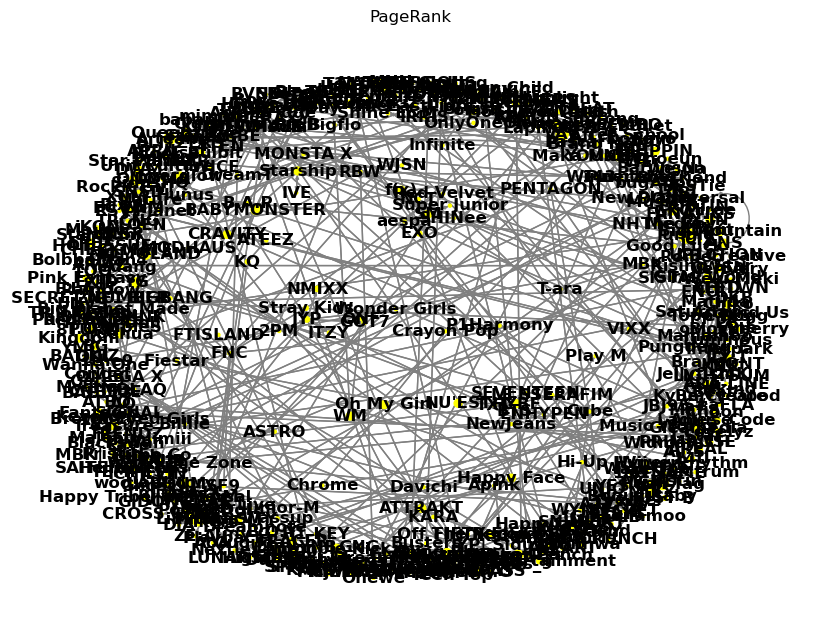

In [189]:
plt.figure(figsize=(8,6))

node_types={'Group':'group', 'Company':'company'}
color = []
for node in G:
    if node_types.get(node) == 'group':
        color.append('purple')
    else:
        color.append('yellow')

node_size = [v[1] * 5000 for v in sorted_pagerank]

pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, with_labels=True, node_color = color, 
       node_size=node_size, edge_color = 'grey', font_size = 12, font_weight = 'bold', arrowsize=5)

plt.title("PageRank")
plt.show()

In [196]:
top_20_pagerank
top_20_pagerank_data = pd.DataFrame(top_20_pagerank, columns=['node', 'rank'])
top_20_pagerank_data

,node,rank
0,HYBE,0.023968
1,SM,0.023968
2,YG,0.016538
3,FNC,0.015174
4,Starship,0.015174
5,JYP,0.013610
6,BTS,0.013551
7,KQ,0.012242
8,ATEEZ,0.010200
9,BLACKPINK,0.010140


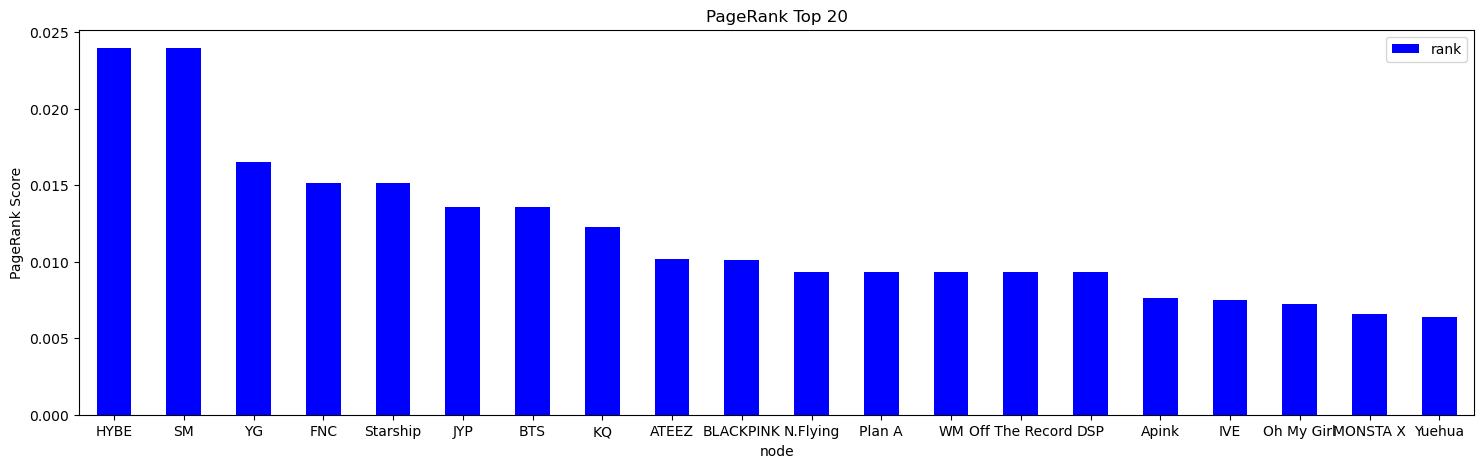

In [197]:
top_20_pagerank_data.plot.bar(x='node', y='rank', rot = 0, color='blue', title='PageRank Top 20', figsize=(18,5))
plt.ylabel('PageRank Score')
plt.show()